# Harsh: Explore a correlation and regression analysis of USG% and TS% and eFG% on BPM and WS and see how strongly shooting efficiency and usage predict overall value, where you can use VORP as a measure to validate.

In [342]:
# Necessary imports to work with and visualize data

# Work with the dataset
import pandas as pd
import numpy as np

# For data visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [343]:
# Load the dataset
df = pd.read_csv("datasets/merged_playerStats.csv")
df.head()

,Player,height,weight,college,Year,Pos,Age,G,MP,PER,...,3P%,2P%,eFG%,FT%,TRB,AST,STL,BLK,TOV,PTS
0,Curly Armstrong,180.0,77.0,Indiana University,1950.50,G-F,31.50,50.500000,NaN,NaN,...,NaN,0.290663,0.290663,0.682050,NaN,138.752475,NaN,NaN,NaN,361.683168
1,Cliff Barker,188.0,83.0,University of Kentucky,1951.00,SG,30.00,49.666667,494.000000,NaN,...,NaN,0.305047,0.305047,0.650389,NaN,99.738255,NaN,NaN,NaN,186.087248
2,Leo Barnhorst,193.0,86.0,University of Notre Dame,1952.00,SF,27.00,68.800000,2426.333333,NaN,...,NaN,0.362035,0.362035,0.676922,NaN,223.758721,NaN,NaN,NaN,646.636628
3,Ed Bartels,196.0,88.0,North Carolina State University,1950.25,F,24.25,11.750000,NaN,NaN,...,NaN,0.252489,0.252489,0.547170,NaN,16.255319,NaN,NaN,NaN,62.638298
4,Ralph Beard,178.0,79.0,University of Kentucky,1950.50,G,22.50,63.000000,NaN,NaN,...,NaN,0.365619,0.365619,0.768810,NaN,277.523810,NaN,NaN,NaN,1008.142857


In [344]:
# Check the max, min, std, etc.
df.describe()

,height,weight,Year,Age,G,MP,PER,TS%,USG%,WS,...,3P%,2P%,eFG%,FT%,TRB,AST,STL,BLK,TOV,PTS
count,3921.000000,3921.000000,3921.000000,3916.000000,3921.000000,3768.000000,3644.000000,3838.000000,2687.000000,3884.000000,...,1467.000000,3797.000000,3826.000000,3231.000000,3698.000000,3921.000000,2945.000000,2945.000000,2692.000000,3921.000000
mean,198.704922,94.783219,1989.638678,25.246681,40.671245,825.525793,11.144763,0.470477,18.823500,1.693137,...,0.273260,0.424702,0.428152,0.700624,175.074037,87.486911,32.034199,19.102526,57.636417,387.430589
std,9.269761,12.039515,19.849659,2.631352,22.003857,708.789110,6.275854,0.098998,4.930042,2.248963,...,0.137963,0.105970,0.105792,0.137385,178.850965,102.801143,30.382227,27.327206,51.779465,376.738511
min,160.000000,60.000000,1950.000000,18.500000,1.000000,0.000000,-48.600000,0.000000,0.000000,-1.880328,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,190.000000,86.000000,1976.000000,23.000000,22.500000,193.875000,8.936988,0.431000,15.704590,0.042334,...,0.216300,0.382000,0.384056,0.641036,36.000000,14.000000,7.000000,2.448980,13.667893,77.024390
50%,198.000000,95.000000,1992.529412,25.000000,43.571429,661.833333,11.539238,0.488260,18.479487,0.862052,...,0.303132,0.441647,0.446637,0.721000,125.740751,52.333333,24.589391,9.206037,45.043011,286.428571
75%,206.000000,102.000000,2007.000000,27.000000,59.421053,1341.303030,13.900000,0.524811,21.403411,2.684276,...,0.350344,0.479000,0.485804,0.784000,253.053258,123.500000,49.251208,23.723077,87.499317,582.632701
max,231.000000,163.000000,2017.000000,36.666667,82.000000,3197.500000,88.300000,1.136000,56.600000,17.950769,...,1.000000,1.000000,1.500000,1.000000,1740.205725,844.291223,202.070755,282.593143,298.094311,2373.388060


In [345]:
# column types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3921 entries, 0 to 3920
Data columns (total 26 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Player   3921 non-null   object 
 1   height   3921 non-null   float64
 2   weight   3921 non-null   float64
 3   college  3573 non-null   object 
 4   Year     3921 non-null   float64
 5   Pos      3921 non-null   object 
 6   Age      3916 non-null   float64
 7   G        3921 non-null   float64
 8   MP       3768 non-null   float64
 9   PER      3644 non-null   float64
 10  TS%      3838 non-null   float64
 11  USG%     2687 non-null   float64
 12  WS       3884 non-null   float64
 13  BPM      2945 non-null   float64
 14  VORP     2945 non-null   float64
 15  FG%      3826 non-null   float64
 16  3P%      1467 non-null   float64
 17  2P%      3797 non-null   float64
 18  eFG%     3826 non-null   float64
 19  FT%      3231 non-null   float64
 20  TRB      3698 non-null   float64
 21  AST      3921 

In [346]:
# find shape of data
df.shape

(3921, 26)

In [347]:
# Unit of observation
len(df['Player'].unique()) # Confirms that each entry is a unique player


3921

In [348]:
# For the sub-goal I am analyzing I will be focusing on USG%, TS%, and eFG% and how
# they relate to the advanced performance metrics: BPM, VORP, and WS

# To start I will check the value counts for the advanced metrics to see the few most common values
print(df['BPM'].value_counts())
print(df['VORP'].value_counts())
print(df['WS'].value_counts())

BPM
-4.900000    13
-4.000000    11
-6.100000    11
-4.500000    11
-4.400000    11
             ..
-0.274706     1
-0.477184     1
-4.075789     1
 2.630371     1
-2.903011     1
Name: count, Length: 2503, dtype: int64
VORP
 0.000000    243
-0.100000    198
-0.200000     96
-0.300000     54
-0.400000     33
            ... 
 0.777533      1
 0.731949      1
 1.339424      1
-0.276316      1
-0.451754      1
Name: count, Length: 2195, dtype: int64
WS
 0.000000    278
-0.100000    176
 0.100000    105
-0.200000     79
 0.200000     67
            ... 
-0.400000      1
 7.618206      1
 1.736400      1
 5.189474      1
 4.217199      1
Name: count, Length: 2883, dtype: int64


In [349]:
# Check the value counts for the metrics we are actually analyzing
print(df['USG%'].value_counts())
print(df['TS%'].value_counts())
print(df['eFG%'].value_counts())

USG%
15.700000    10
19.200000     9
18.500000     8
22.000000     8
17.200000     7
             ..
22.800000     1
19.726923     1
15.260714     1
31.300000     1
6.400000      1
Name: count, Length: 2312, dtype: int64
TS%
0.000000    35
0.333000    17
0.250000    12
0.388000    11
0.500000    11
            ..
0.589332     1
0.571606     1
0.493342     1
0.499282     1
0.506512     1
Name: count, Length: 3230, dtype: int64
eFG%
0.000000    57
0.333000    38
0.500000    35
0.250000    32
0.400000    17
            ..
0.464608     1
0.466504     1
0.473687     1
0.466757     1
0.480696     1
Name: count, Length: 3174, dtype: int64


### Curious about why there are a significant amount of 0's for VORP, WS, TS%, and eFG%. Is it because they had no impact, or is it because they weren't tracked

In [350]:
# Check the distribution for the stats and then plot it as well
df[df["USG%"] == 0].describe()

,height,weight,Year,Age,G,MP,PER,TS%,USG%,WS,...,3P%,2P%,eFG%,FT%,TRB,AST,STL,BLK,TOV,PTS
count,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,0.0,7.0,7.0,...,0.0,0.0,0.0,0.0,7.000000,7.000000,7.0,7.0,7.0,7.0
mean,203.714286,105.285714,2004.142857,24.000000,1.428571,2.714286,0.942857,NaN,0.0,0.0,...,NaN,NaN,NaN,NaN,0.714286,0.142857,0.0,0.0,0.0,0.0
std,9.928314,15.250293,8.173709,1.732051,0.786796,1.889822,7.126911,NaN,0.0,0.0,...,NaN,NaN,NaN,NaN,1.112697,0.377964,0.0,0.0,0.0,0.0
min,183.000000,81.000000,1992.000000,22.000000,1.000000,1.000000,-9.100000,NaN,0.0,0.0,...,NaN,NaN,NaN,NaN,0.000000,0.000000,0.0,0.0,0.0,0.0
25%,203.500000,96.500000,2000.000000,23.000000,1.000000,1.000000,-2.150000,NaN,0.0,0.0,...,NaN,NaN,NaN,NaN,0.000000,0.000000,0.0,0.0,0.0,0.0
50%,206.000000,106.000000,2003.000000,23.000000,1.000000,2.000000,0.000000,NaN,0.0,0.0,...,NaN,NaN,NaN,NaN,0.000000,0.000000,0.0,0.0,0.0,0.0
75%,208.500000,116.500000,2008.500000,25.000000,1.500000,4.500000,3.900000,NaN,0.0,0.0,...,NaN,NaN,NaN,NaN,1.000000,0.000000,0.0,0.0,0.0,0.0
max,213.000000,124.000000,2017.000000,27.000000,3.000000,5.000000,12.200000,NaN,0.0,0.0,...,NaN,NaN,NaN,NaN,3.000000,1.000000,0.0,0.0,0.0,0.0


### When players have a USG% of 0, that means they are not involved in the team's offensive plays. Judging by the Games column here, they also do not get much playing time either.

In [351]:
df[df["TS%"] == 0].describe()

,height,weight,Year,Age,G,MP,PER,TS%,USG%,WS,...,3P%,2P%,eFG%,FT%,TRB,AST,STL,BLK,TOV,PTS
count,35.000000,35.000000,35.000000,35.000000,35.000000,34.000000,34.000000,35.0,27.000000,35.000000,...,9.0,33.0,35.0,1.0,34.000000,35.000000,28.000000,28.000000,27.000000,35.0
mean,199.885714,95.171429,1994.100000,23.928571,2.328571,7.799020,-13.463305,0.0,18.637478,-0.045510,...,0.0,0.0,0.0,0.0,1.028711,0.400000,0.265306,0.035714,0.661376,0.0
std,11.289692,11.338341,20.214948,2.288536,1.419107,7.554491,15.791843,0.0,13.160783,0.061934,...,0.0,0.0,0.0,NaN,1.493335,0.553066,0.516858,0.188982,0.998545,0.0
min,178.000000,78.000000,1950.000000,19.000000,1.000000,1.000000,-48.600000,0.0,4.000000,-0.200000,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
25%,191.500000,86.500000,1987.500000,23.000000,1.000000,3.250000,-20.375000,0.0,9.650000,-0.100000,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
50%,201.000000,95.000000,2000.000000,24.000000,2.000000,6.000000,-11.350000,0.0,14.200000,0.000000,...,0.0,0.0,0.0,0.0,0.916667,0.000000,0.000000,0.000000,0.000000,0.0
75%,208.000000,105.000000,2009.500000,24.000000,3.000000,9.750000,-0.825000,0.0,23.914286,0.000000,...,0.0,0.0,0.0,0.0,1.000000,1.000000,0.107143,0.000000,1.000000,0.0
max,226.000000,124.000000,2017.000000,30.000000,6.000000,43.000000,15.500000,0.0,46.600000,0.000000,...,0.0,0.0,0.0,0.0,7.000000,2.000000,2.000000,1.000000,3.000000,0.0


In [352]:
df[df["eFG%"] == 0].describe()

,height,weight,Year,Age,G,MP,PER,TS%,USG%,WS,...,3P%,2P%,eFG%,FT%,TRB,AST,STL,BLK,TOV,PTS
count,57.000000,57.000000,57.000000,57.000000,57.000000,53.000000,53.000000,57.000000,36.000000,57.000000,...,16.0,55.0,57.0,23.000000,54.000000,57.000000,37.000000,37.000000,36.000000,57.000000
mean,198.473684,93.000000,1986.236842,23.991228,3.026316,11.361635,-9.446271,0.080386,19.878108,-0.059524,...,0.0,0.0,0.0,0.649478,2.018078,0.789474,0.498069,0.135135,0.996032,1.052632
std,10.138514,11.378237,22.701106,2.036478,2.023128,9.855458,14.409604,0.123830,12.724949,0.068263,...,0.0,0.0,0.0,0.275804,2.432677,1.160924,1.118096,0.419137,1.265135,1.903203
min,178.000000,77.000000,1950.000000,19.000000,1.000000,1.000000,-48.600000,0.000000,4.000000,-0.300000,...,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,190.000000,83.000000,1966.000000,23.000000,2.000000,5.000000,-15.200000,0.000000,11.525000,-0.100000,...,0.0,0.0,0.0,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,198.000000,92.000000,1990.000000,24.000000,2.000000,9.000000,-8.300000,0.000000,15.800000,-0.100000,...,0.0,0.0,0.0,0.667000,1.000000,0.000000,0.000000,0.000000,0.428571,0.000000
75%,203.000000,104.000000,2006.000000,25.000000,4.000000,13.000000,0.500000,0.145000,25.007143,0.000000,...,0.0,0.0,0.0,0.916500,3.000000,1.000000,1.000000,0.000000,2.000000,2.000000
max,226.000000,124.000000,2017.000000,30.000000,10.000000,43.000000,15.500000,0.431000,49.800000,0.100000,...,0.0,0.0,0.0,1.000000,12.000000,5.000000,6.000000,2.000000,5.000000,11.000000


### Now there is a base understanding of the values of the dataset, so using histograms we can visualize the distribution better before deciding where to subset.

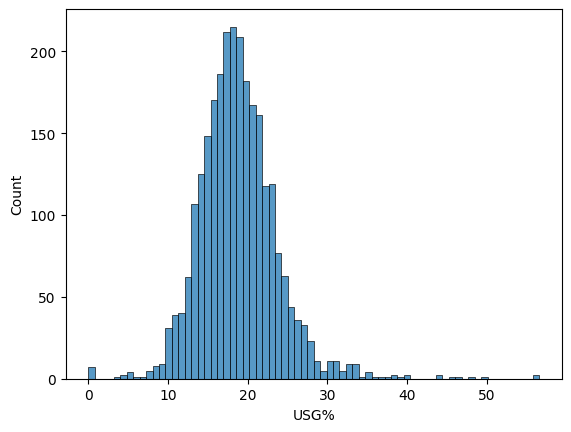

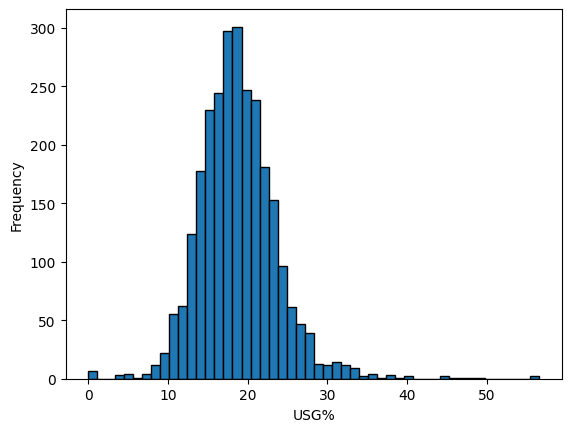

In [353]:
# Univariate analysis of variables of interest

# Look at the univariate plot of the Usage% with seaborn histogram
sns.histplot(df['USG%'])
plt.show()

# Look at the univariate plot of the Usage% with matplotlib histogram
plt.hist(df['USG%'], bins=50, edgecolor='black')
plt.xlabel('USG%')
plt.ylabel('Frequency')
plt.show()

# I prefer the seaborn plot since it takes care of deducing bin size for a relatively normal distribution

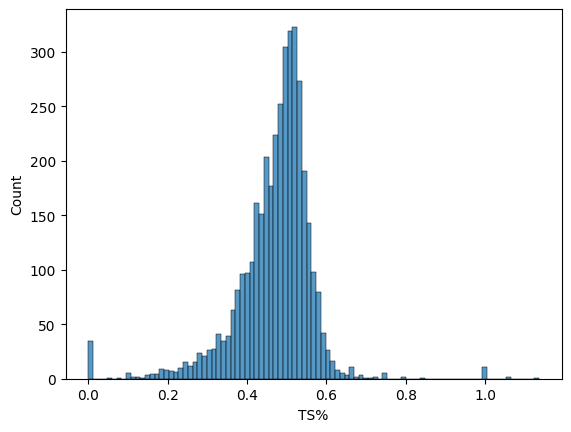

In [354]:
# Look at the univariate plot of the TS% with seaborn histogram
sns.histplot(df['TS%'])
plt.show()

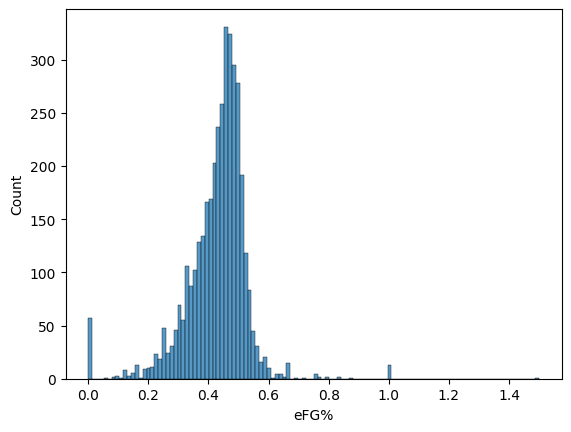

In [355]:
# Look at the univariate plot of the TS% with seaborn histogram
sns.histplot(df['eFG%'])
plt.show()

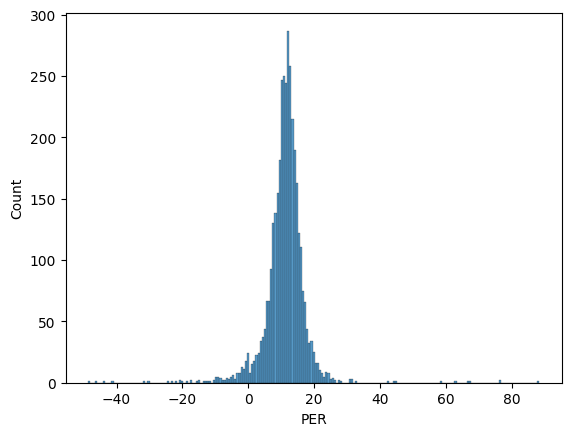

In [356]:
# Look at the univariate plot of the TS% with seaborn histogram
sns.histplot(df['PER'])
plt.show()

### Perhaps it is also worth taking a look at the plot of the advanced performance metrics we are analyzing against

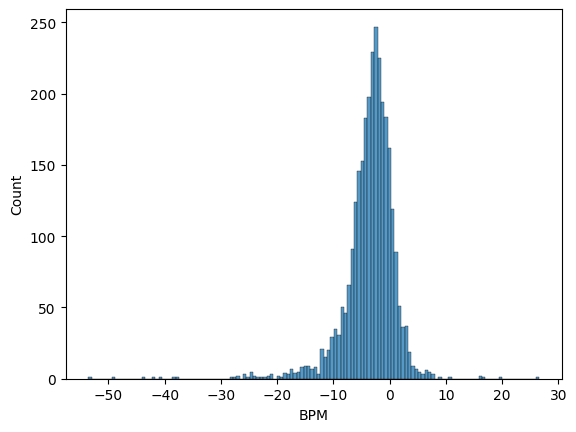

In [357]:
# Look at the univariate plot of the BPM with seaborn histogram
sns.histplot(df['BPM'])
plt.show()

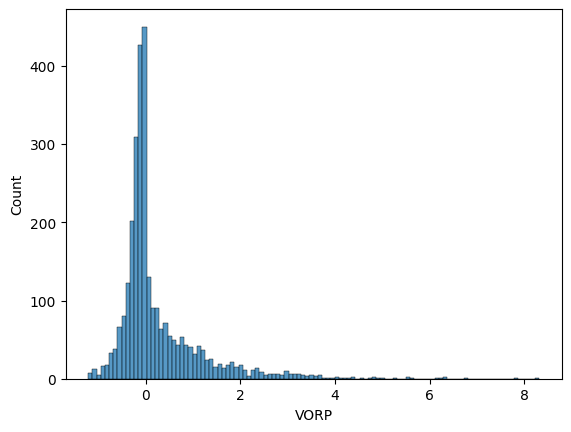

In [358]:
# Look at the univariate plot of the BPM with seaborn histogram
sns.histplot(df['VORP'])
plt.show()

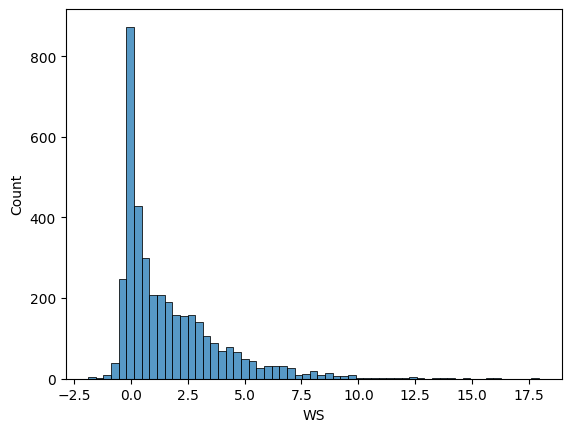

In [359]:
# Look at the univariate plot of the BPM with seaborn histogram
sns.histplot(df['WS'])
plt.show()

### Scatterplots and Heatmaps may also provide some useful insights. We can also consider checking out Boxplots after those two and then maybe the Kernel Density plot later on once we have subset the data.

<Axes: xlabel='USG%', ylabel='WS'>

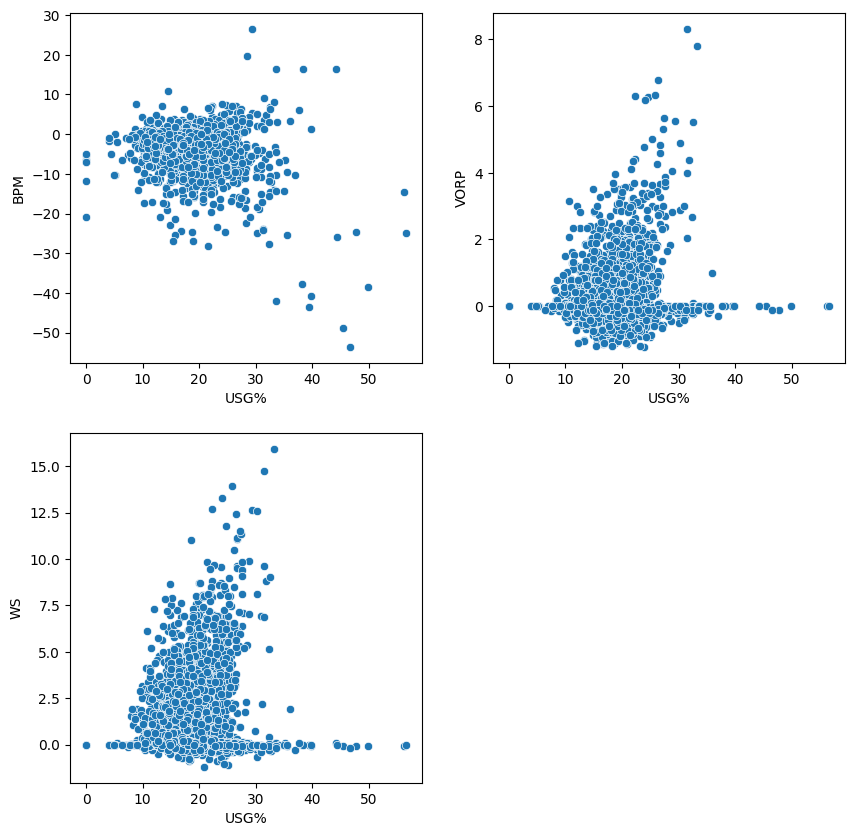

In [360]:
# Scatter plots: Try out the different options of eFG%, TS%, USG% with the BPM, VORP, WS

plt.figure(figsize=(10, 10))

# USG% by BPM
plt.subplot(2, 2, 1)
sns.scatterplot(data=df, x='USG%', y='BPM')
# USG% by VORP
plt.subplot(2, 2, 2)
sns.scatterplot(data=df, x='USG%', y='VORP')
# USG% by WS
plt.subplot(2, 2, 3)
sns.scatterplot(data=df, x='USG%', y='WS')

<Axes: xlabel='TS%', ylabel='WS'>

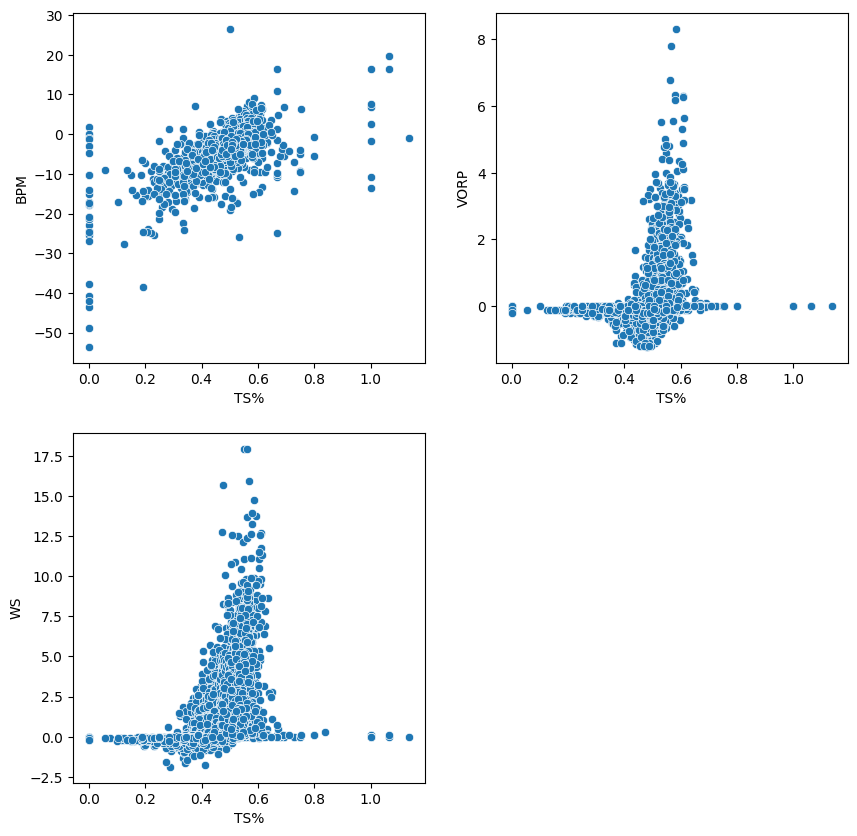

In [361]:
plt.figure(figsize=(10, 10))

# TS% by BPM
plt.subplot(2, 2, 1)
sns.scatterplot(data=df, x='TS%', y='BPM')
# TS% by VORP
plt.subplot(2, 2, 2)
sns.scatterplot(data=df, x='TS%', y='VORP')
# TS% by WS
plt.subplot(2, 2, 3)
sns.scatterplot(data=df, x='TS%', y='WS')

<Axes: xlabel='eFG%', ylabel='WS'>

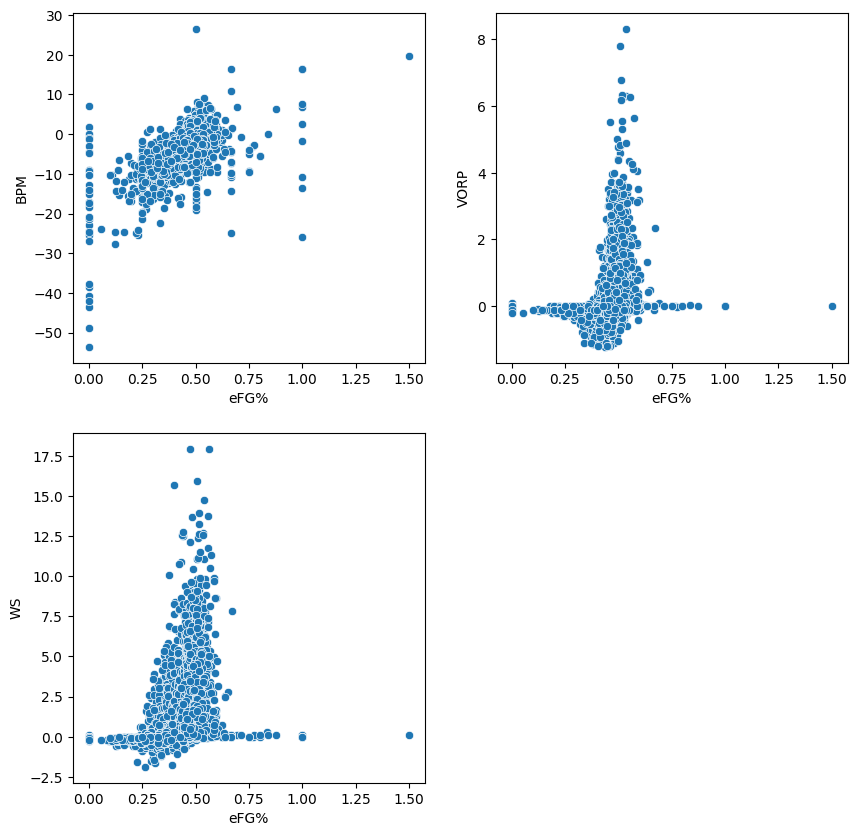

In [362]:
plt.figure(figsize=(10, 10))

# eFG% by BPM
plt.subplot(2, 2, 1)
sns.scatterplot(data=df, x='eFG%', y='BPM')
# eFG% by VORP
plt.subplot(2, 2, 2)
sns.scatterplot(data=df, x='eFG%', y='VORP')
# eFG% by WS
plt.subplot(2, 2, 3)
sns.scatterplot(data=df, x='eFG%', y='WS')

<Axes: xlabel='PER', ylabel='WS'>

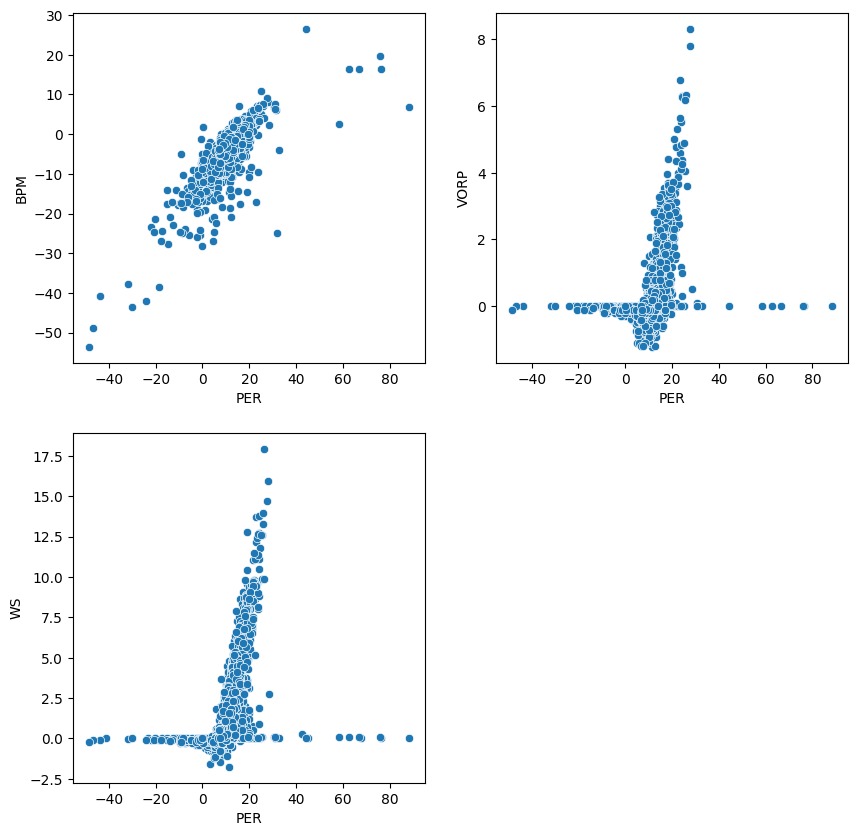

In [363]:
plt.figure(figsize=(10, 10))

# PER by BPM
plt.subplot(2, 2, 1)
sns.scatterplot(data=df, x='PER', y='BPM')
# PER by VORP
plt.subplot(2, 2, 2)
sns.scatterplot(data=df, x='PER', y='VORP')
# PER by WS
plt.subplot(2, 2, 3)
sns.scatterplot(data=df, x='PER', y='WS')

Looking at these plots provides some solid information. There are some data points that clearly need to be dropped, such as those that indicate a TS% over 100% or a eFG% over 100%.

---

**USG% by BPM** - Clustered, but not super clear relationship, other than very high usage seems to indicate low BPM, high usage doesn't guarantee value (inefficient scorers), generally ~20-30% seems to be a good range for USG% to provide the best BPM

**USG% by VORP** - Positive correlation from ~10-30 USG%, highest VORPs within ~20-30 USG%, lots of values spread across 0 VORP


**USG% by WS** - Positive correlation from ~10-30 USG%, highest WSs within ~20-30 USG%,lots of values spread across 0 WS

---

**TS% by BPM** - Generally linear and positive relationship, low TS% = very low BPM

**TS% by VORP** - Lots of data points spread across values of VORP around 50% True Shooting, (Triangle/Narrow Bell Curve shape), lots of 0 values

**TS% by WS** - Similar to TS% by VORP, lots of data points spread across values of WS with 50% True Shooting, (Triangle/Narrow Bell Curve shape), lots of 0 values

Higher TS% correlates with higher WS and VORP, this is similar with eFG%

For a quick explanation, those players that consistently keep up their shooting efficiency with decent volume have a decent value/contribution, but those players with a high efficiency but don't have many attempts can be seen clearly on the right side of the curve, indicating that they aren't playing much or aren't taking enough attempts to have an impact with their efficient performance.

---

**eFG% by BPM** - Similar to TS% by BPM, though less spread out which can be explained by how the metric is calculated in comparison to TS% I would say (see the datasheet/dictionary if you actually wanna know the formula), low eFG% = very low BPM

**eFG% by VORP** - Lots of data points spread across values of VORP around 50% True Shooting, lots of 0 values, (Triangle/Narrow Bell Curve shape)

**eFG% by WS** - Similar to TS% by VORP, lots of data points spread across values of WS with 50% True Shooting, lots of 0 values, (Triangle/Narrow Bell Curve shape)

Higher eFG correlates with higher WS and VORP

---

**PER by BPM** - Well correlated positive linear relationship

**PER by VORP** - Lots of data points spread across values of VORP from 0-20 PER, but generally the higher PER = higher VORP, (Triangle/Narrow Bell Curve shape), lots of 0 values

**PER by WS** - Similar to PER by VORP, Lots of data points spread across values of WS from 0-20 PER, but generally the higher PER = higher WS, (Triangle/Narrow Bell Curve shape), lots of 0 values

---

### Correlational Heatmap Plot for multivariate analysis

In [364]:
# Correlational Heatmap Plot for multivariate analysis

# Using all the variables we've been working with, along with G and MP for context of efficiency
df_subset = df[["USG%", "TS%", "eFG%", "BPM", "VORP", "WS", "G", "MP", "PER"]]
df_subset.head()

,USG%,TS%,eFG%,BPM,VORP,WS,G,MP,PER
0,NaN,0.369505,0.290663,NaN,NaN,2.408911,50.500000,NaN,NaN
1,NaN,0.365362,0.305047,NaN,NaN,0.677852,49.666667,494.000000,NaN
2,NaN,0.395567,0.362035,NaN,NaN,NaN,68.800000,2426.333333,NaN
3,NaN,0.311809,0.252489,NaN,NaN,-0.538298,11.750000,NaN,NaN
4,NaN,0.428810,0.365619,NaN,NaN,5.690476,63.000000,NaN,NaN


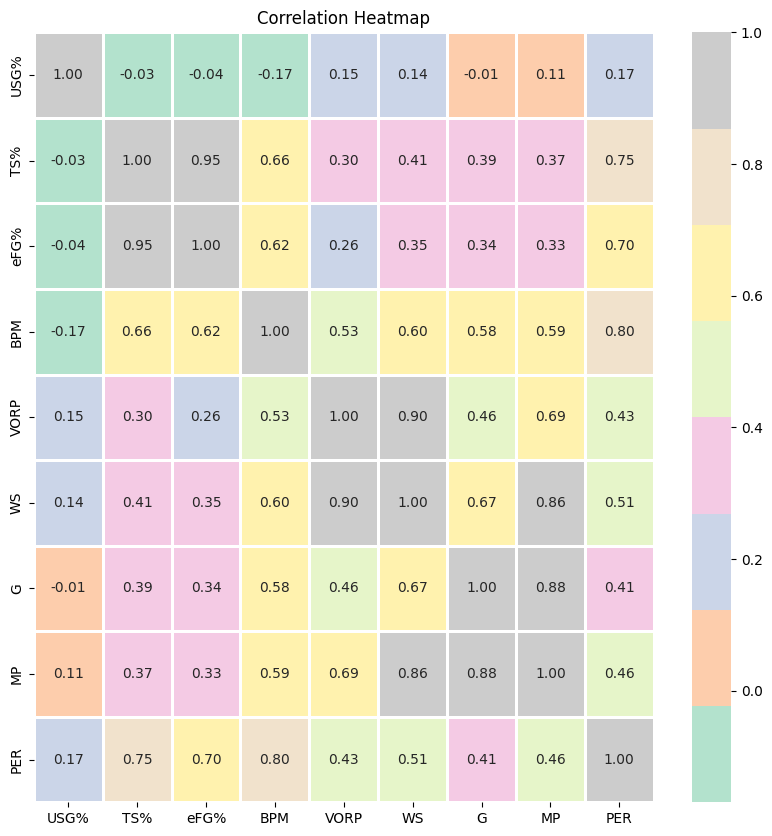

In [365]:
plt.figure(figsize=(10, 10))
sns.heatmap(df_subset.corr(), annot=True, fmt='.2f', cmap='Pastel2', linewidths=2)

plt.title('Correlation Heatmap')
plt.show()

Values close to +1 indicates strong positive correlation, -1 indicates a strong negative correlation and 0 indicates suggests no linear correlation.

The correlation heatmap shows that the following insights:
- USG% alone isn't enough to show correlation, needs some other variable for context
- TS% and eFG% are very closely correlated, TS% is also well correlated to BPM and PER
- BPM is pretty well correlated with TS% and eFG%, slightly more with TS%, indicating that it might be a better metric than eFG%. It is also well correlated with WS, G, and MP. It is best correlated with PER.
- VORP is highly correlated with WS and well correlated with MP, as well as somewhat correlated with BPM, G, and PER
- WS are also well correlated with G and PER, as well as highly correlated with MP
- MP are also highly correlated with G and somewhat corellated with PER.
- PER is highly correlated with TS% and BPM, well correlated with eFG%, and somewhat correlated with VORP, WS, and MP.

Considering that TS% and eFG% are so closely correlated it is redundant to continue to include eFG% and simply have TS%.
I mostly considered that there was at least somewhat of a correlation if the box was light green (0.43) or above.

### Boxplots

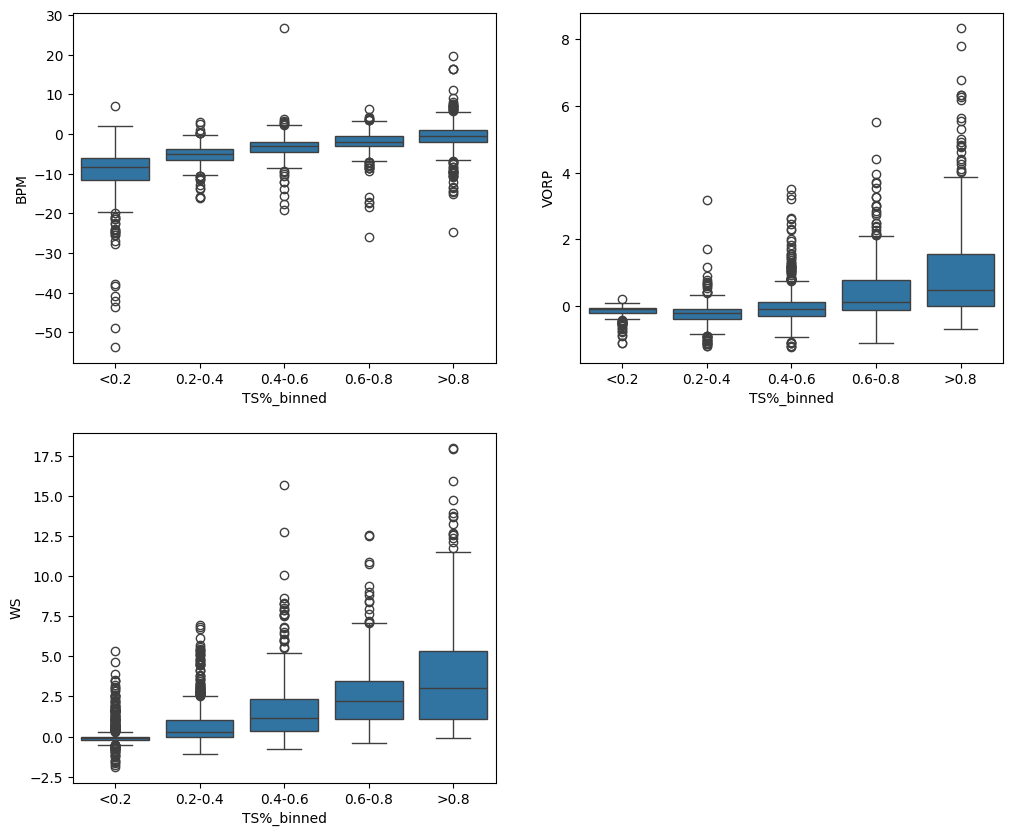

In [366]:
# Explore how the advanced performance metrics (PER, BPM, VORP, WS) vary across different efficiencies

# Need to make some fixed width bins since TS% is continuous and it does NOT look like what
# I expected when I plotted it outright. I think it made each unique value as a category.

plt.figure(figsize=(12, 10))

# Split the data into five equal quartile buckets (Tried doing fixed, equal-width buckets, but didn't look as clear)
ts_labels = ['<0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '>0.8']
df['TS%_binned'] = pd.qcut(df['TS%'], q=5, labels=ts_labels)

# make a boxplot for each of the performance variables
plt.subplot(2, 2, 1)
sns.boxplot(x='TS%_binned', y='BPM', data=df)
plt.subplot(2, 2, 2)
sns.boxplot(x='TS%_binned', y='VORP', data=df)
plt.subplot(2, 2, 3)
sns.boxplot(x='TS%_binned', y='WS', data=df)

plt.show()

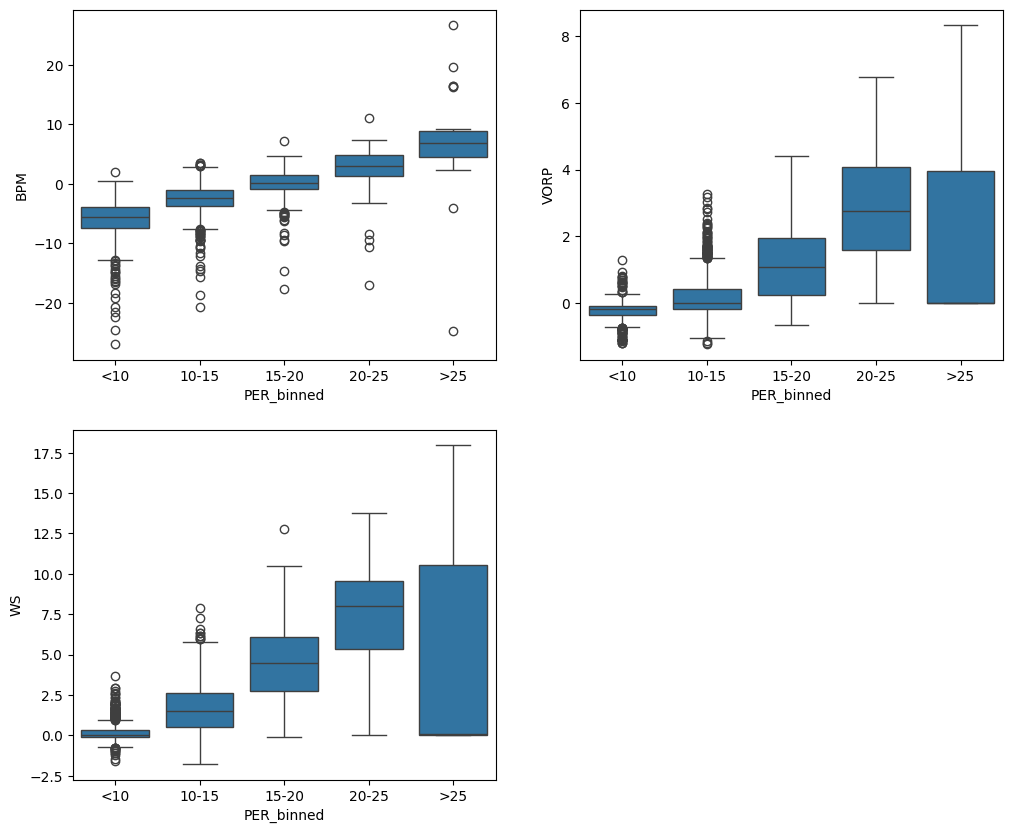

In [367]:
# Do the same thing but with PER instead
# League average is around 15 PER

plt.figure(figsize=(12, 10))

# Split the data into using custom bins
per_labels = ['<10', '10-15', '15-20', '20-25', '>25']
df['PER_binned'] = pd.cut(df['PER'], bins=[0, 10, 15, 20, 25, 100], labels=per_labels)

# make a boxplot for each of the performance variables
plt.subplot(2, 2, 1)
sns.boxplot(x='PER_binned', y='BPM', data=df)
plt.subplot(2, 2, 2)
sns.boxplot(x='PER_binned', y='VORP', data=df)
plt.subplot(2, 2, 3)
sns.boxplot(x='PER_binned', y='WS', data=df)

plt.show()


### Usage% Cooler Scatterplots

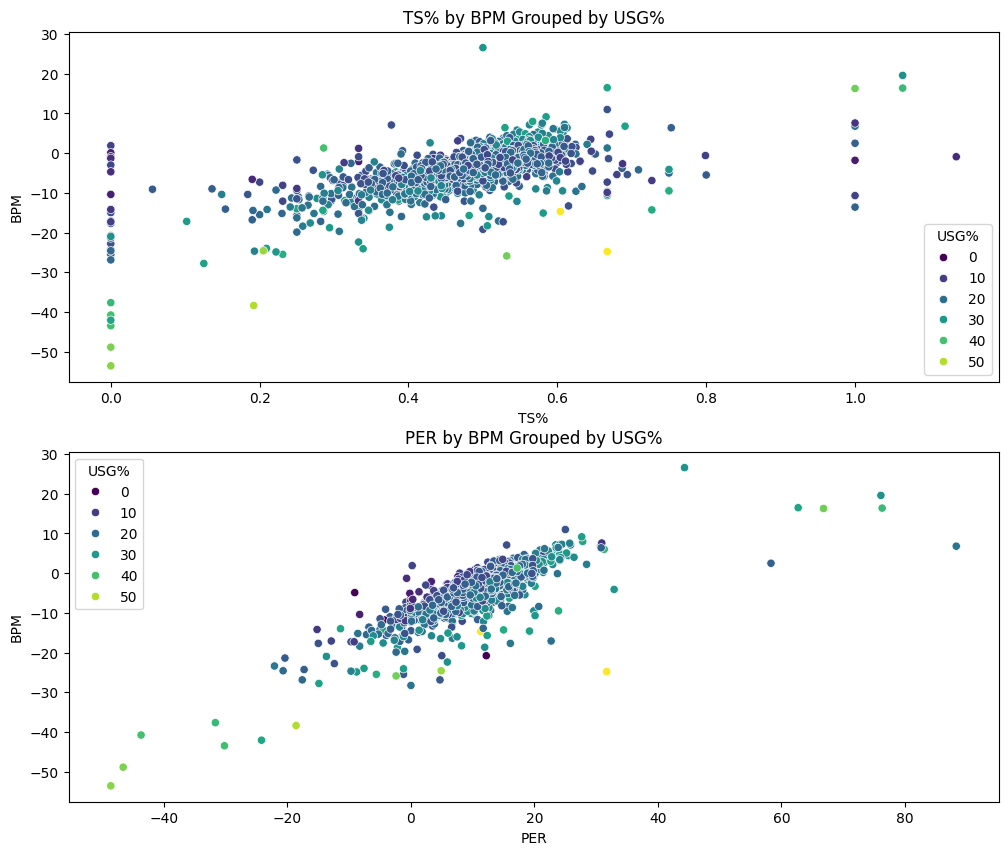

In [368]:
# We have already looked at the USG% correlations and indiviually it doesn't mean much,
# but maybe put it together with another metric like TS%

plt.figure(figsize=(12, 10))

# Put the plot of TS% by BPM, but have the hue of the points change depending on the USG%
plt.subplot(2, 1, 1)
sns.scatterplot(data=df, x='TS%', y='BPM', hue="USG%", palette="viridis")
plt.title('TS% by BPM Grouped by USG%')

# Put the plot of PER by BPM, but have the hue of the points change depending on the USG%
plt.subplot(2, 1, 2)
plt.title('PER by BPM Grouped by USG%')
sns.scatterplot(data=df, x='PER', y='BPM', hue="USG%", palette="viridis")

plt.show()

PER by BPM grouped by USG% shows interesting results, such as those with greater PER are having higher USG% and they generally have a decent BPM.

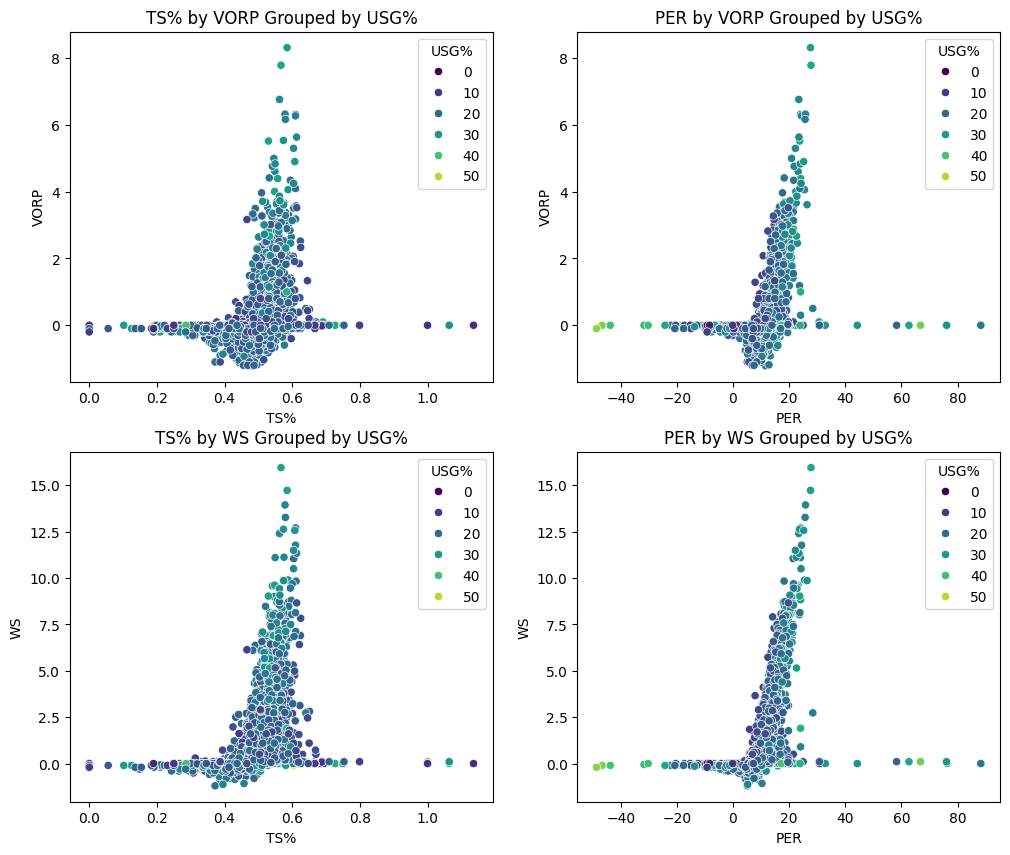

In [369]:
# Do the other performance metrics
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
plt.title('TS% by VORP Grouped by USG%')
sns.scatterplot(data=df, x='TS%', y='VORP', hue="USG%", palette="viridis")

plt.subplot(2, 2, 2)
plt.title('PER by VORP Grouped by USG%')
sns.scatterplot(data=df, x='PER', y='VORP', hue="USG%", palette="viridis")

plt.subplot(2, 2, 3)
plt.title('TS% by WS Grouped by USG%')
sns.scatterplot(data=df, x='TS%', y='WS', hue="USG%", palette="viridis")

plt.subplot(2, 2, 4)
plt.title('PER by WS Grouped by USG%')
sns.scatterplot(data=df, x='PER', y='WS', hue="USG%", palette="viridis")
plt.show()

Results seem reasonable, since the higher up the curve is the lighter data points indicating greater usage. TS% by VORP likely has the significant number of 20% USG players that have below 0 VORP due to them being role players that  aren't actually doing as well as a theoretical replacement player could. I wouldn't be surprised if these were those 3-point specialists that can be very streaky and unreliable on defense.

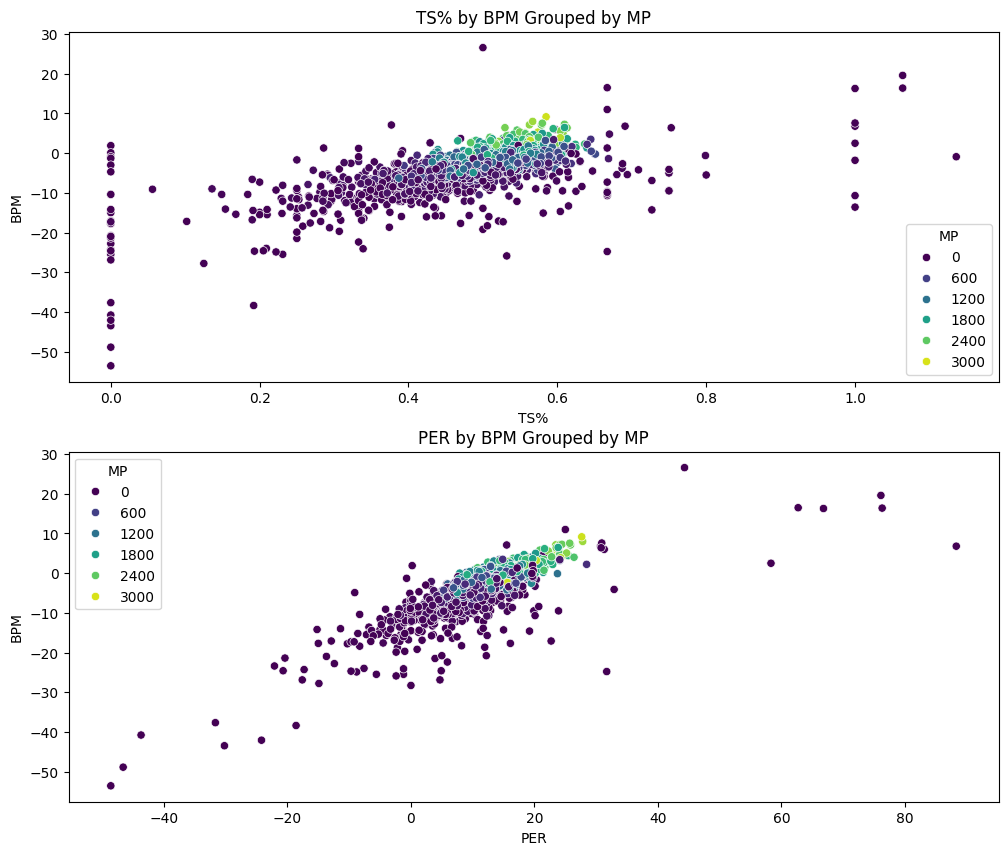

In [370]:
plt.figure(figsize=(12, 10))

# Minutes played is also a good one that needs another variable to get context
plt.subplot(2, 1, 1)
plt.title('TS% by BPM Grouped by MP')
sns.scatterplot(data=df, x='TS%', y='BPM', hue="MP", palette="viridis")

plt.subplot(2, 1, 2)
plt.title('PER by BPM Grouped by MP')
sns.scatterplot(data=df, x='PER', y='BPM', hue="MP", palette="viridis")
plt.show()

It looks like the BPM has a lot of players that are getting hardly any playing time, this seems like something worth considering and keeping in mind for context.

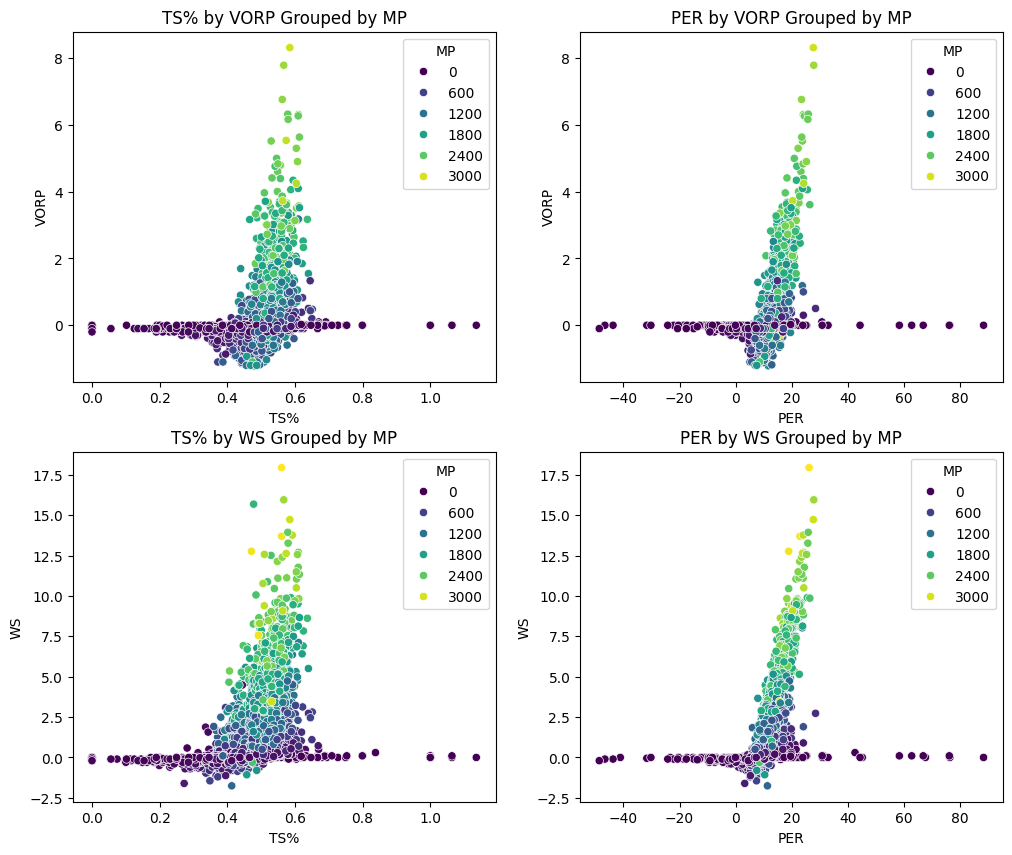

In [371]:
# Should also do VORP and WS since MP showed good correlation there
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
plt.title('TS% by VORP Grouped by MP')
sns.scatterplot(data=df, x='TS%', y='VORP', hue="MP", palette="viridis")

plt.subplot(2, 2, 2)
plt.title('PER by VORP Grouped by MP')
sns.scatterplot(data=df, x='PER', y='VORP', hue="MP", palette="viridis")

plt.subplot(2, 2, 3)
plt.title('TS% by WS Grouped by MP')
sns.scatterplot(data=df, x='TS%', y='WS', hue="MP", palette="viridis")

plt.subplot(2, 2, 4)
plt.title('PER by WS Grouped by MP')
sns.scatterplot(data=df, x='PER', y='WS', hue="MP", palette="viridis")
plt.show()

The 0 values of WS and VORP make a lot more sense knowing that it was due to those players with almost no playing time, but having varying ranges in their PER and TS%. If we remove those, then we can really focus on the triangular clump.

### Filter and Subset the Data!!!


In [372]:
# Remove the rows where MP are less than 480 (That is less than 10 games worth of play time)
# Remove the weird values where TS% were above 80% since that is mostly an outlier and will also be covered by the
# filter to remove those who did not play often
# Remove the PERs over 40, since the single season record for PER is 32.85
df_filtered = df[(df['MP'] >= 480) & (df['TS%'] <= 0.8) & (df['PER'] <= 40)]

# I feel like there isn't much need to filter more than this other than considering
# removing those with MP under 480 should get rid of most outliers

# Keep just the columns we are working with here
df_filtered = df_filtered[["Player", "USG%", "TS%", "PER", "BPM", "VORP", "WS", "MP"]]

# Remove the rows where all of the performance metrics (BPM, VORP, WS) are NaN
# This allows us to actually see the values of the variables, so that the model
# doesn't underperform due to fitting to the NaN values
df_filtered = df_filtered.dropna(subset=['BPM', 'VORP', 'WS', 'USG%'])

# (1474, 8)
print(df_filtered.shape)
df_filtered.head()

(1474, 8)


,Player,USG%,TS%,PER,BPM,VORP,WS,MP
1229,Tate Armstrong,18.343478,0.472587,9.800000,-5.295652,-0.443478,0.258696,487.500000
1230,Greg Ballard,19.441272,0.507756,15.287905,1.015586,1.944264,5.390025,2006.636364
1231,Kent Benson,16.870916,0.528908,13.832537,0.665604,1.203187,3.475033,1354.615385
1232,Otis Birdsong,24.223420,0.528111,16.077586,-0.011782,1.353161,5.001868,1802.250000
1236,Mike Bratz,19.215870,0.474386,11.704608,-2.827986,-0.096928,1.493174,1179.222222


# Stepwise Regression

In [373]:
# Linear Regression imports
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from mlxtend.feature_selection import SequentialFeatureSelector as sfs

# Independent variables: PER, TS%, USG%
# Dependent variables: BPM, VORP, WS

# Plan:
# - TS%
# - TS%, USG%
# - TS%, USG%, PER
# - TS%, USG%, PER, TS%*USG%
# - PER
# - PER, USG%
# Basically capture all of the different variables alone and combined

### BPM Regression

In [374]:
# BPM Regression

# Perform stepwise regression with crossval to avoid overfitting
df_bpm = df_filtered.copy()

# Make new column to show the relationship
df_bpm["TS%*USG%"] = df_bpm["TS%"] * df_bpm["USG%"]
df_bpm["PER*USG%"] = df_bpm["PER"] * df_bpm["USG%"]

X = df_bpm[["USG%", "TS%", "PER", "TS%*USG%", "PER*USG%"]]
y = df_bpm["BPM"]

# Split data into training and testing sets
# 70-30 training testing split
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.3, random_state=42)

# Create model
model_BPM = LinearRegression()
sfs_step_BPM = sfs(model_BPM, k_features=(1, 5), forward=True,
               floating= True, # facilitates removing variables
               verbose=2, scoring='r2', cv= 5)

# Fit model
sfs_step_BPM = sfs_step_BPM.fit(train_X, train_y)


[2025-03-31 05:43:07] Features: 1/5 -- score: 0.5892406494543303
[2025-03-31 05:43:07] Features: 2/5 -- score: 0.6914927856083702
[2025-03-31 05:43:07] Features: 3/5 -- score: 0.7035970289733731
[2025-03-31 05:43:07] Features: 4/5 -- score: 0.7043763523322176
[2025-03-31 05:43:07] Features: 5/5 -- score: 0.7043384363821266

In [375]:
# BPM Regression Continued...

# print features that were included in the BPM model
feat_names = list(sfs_step_BPM.k_feature_names_)
print(f"Features: {feat_names}")

# Create a dataframe with only the selected features
df_bpm_selected = df_bpm[feat_names]

# Split the data into updated train test splits
train_X_selected = train_X[feat_names]
test_X_selected = test_X[feat_names]

# Fit the model with the selected features
model_BPM.fit(train_X_selected, train_y)

# Make predictions using the test set
y_pred = model_BPM.predict(test_X_selected)

# Evaluate the model performance on r2
r2 = model_BPM.score(test_X_selected, test_y)
print(f"R2: {r2}")

# Print the coefficients
print(f"Intercept: {model_BPM.intercept_}")
print(f"Slope: {model_BPM.coef_}")

Features: ['USG%', 'TS%', 'PER', 'PER*USG%']
R2: 0.7157567206908471
Intercept: -3.3254722548660833
Slope: [-0.45513727  2.68813855  0.37351073  0.01609026]


The model ignored the TS%*USG% feature and kept the other four features.

The model explains about 71.6% of the variance of the BPM, which I would think means the features do a good job of modeling BPM.

With a value of -0.455, USG% is showing a negative influence on BPM, so higher usage is penalized in BPM.

With a value of 2.668, TS% is showing a STRONG positive influence on BPM, so higher shooting efficiency = significantly higher BPM

With a value of 0.374, PER is showing a moderate positive influence on BPM, so increases in PER is a slight increase to BPM.

With a value of 0.016, PER*USG% has a small positive influence on BPM, which is a stark constrast to the -0.455 value that USG% had on its own. So a good PER will counter the negative influence that USG% has.

---

Summary: \
Being a high-usage player doesn't guarantee positive impact, and may instead lower it. However, if you are a efficient shot-maker (high TS%) and generally productive (high PER), then you provide value to the team. Also, being generally productive (high PER) will counteract the decrease in value brought about by a high usage.

### WS Regression

In [376]:
# WS Regressions

# Perform stepwise regression with crossval to avoid overfitting
df_ws = df_filtered.copy()

# Make new column to show the relationship
df_ws["TS%*USG%"] = df_ws["TS%"] * df_ws["USG%"]
df_ws["PER*USG%"] = df_ws["PER"] * df_ws["USG%"]

# I removed PER since it was causing some issues with multicollinearity
X = df_ws[["USG%", "TS%", "TS%*USG%", "PER*USG%"]]
y = df_ws["WS"]

# Split data into training and testing sets
# 70-30 training testing split
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.3, random_state=42)

# Create model
model_WS = LinearRegression()
sfs_step_WS = sfs(model_WS, k_features=(1, 4), forward=True,
               floating= True, # facilitates removing variables
               verbose=2, scoring='r2', cv= 5)

# Fit model
sfs_step_WS = sfs_step_WS.fit(train_X, train_y)


[2025-03-31 05:43:07] Features: 1/4 -- score: 0.48020652689430027
[2025-03-31 05:43:07] Features: 2/4 -- score: 0.7347817365808563
[2025-03-31 05:43:07] Features: 3/4 -- score: 0.7435268156845698
[2025-03-31 05:43:08] Features: 4/4 -- score: 0.7412088811924584

In [377]:
# WS Regression Continued...

# print features that were included in the WS model
feat_names = list(sfs_step_WS.k_feature_names_)
print(f"Features: {feat_names}")

# Create a dataframe with only the selected features
df_ws_selected = df_ws[feat_names]

# Split the data into updated train test splits
train_X_selected = train_X[feat_names]
test_X_selected = test_X[feat_names]

# Fit the model with the selected features
model_WS.fit(train_X_selected, train_y)

# Make predictions using the test set
y_pred = model_WS.predict(test_X_selected)

# Evaluate the model performance on r2
r2 = model_WS.score(test_X_selected, test_y)
print(f"R2: {r2}")

# Print the coefficients
print(f"Intercept: {model_WS.intercept_}")
print(f"Slope: {model_WS.coef_}")

Features: ['USG%', 'TS%', 'PER*USG%']
R2: 0.7796369750952378
Intercept: 1.210915648025554
Slope: [-0.50289738  7.10554997  0.02877813]


The model ignored TS%*USG%.

The model explains about 78.0% of the variance of the WS, which I would think means the features do a good job of modeling WS. This is even better than the model's predictions on BPM.

With a value of -0.503, USG% is showing a negative influence on WS, so higher usage is penalized in WS a little more than it was in BPM.

With a value of 7.106, TS% is showing a STRONG positive influence on WS, so higher shooting efficiency = significantly higher WS. (NOTE: Removed PER to avoid multicollinearity, since otherwise this value was ~ -9.12; See below summary.)

With a value of 0.029, PER*USG% has a small positive influence on WS. This is a combination of the positive PER and negative USG%, so a high PER will counter the negative influence that USG% has.



---

Summary: \
Being a high-usage player doesn't guarantee positive impact, and may instead lower it. Also, if you are a good shooting efficiency (high TS%) you aren bringing value to the team's win. Also, being generally productive (high PER) is nice when paired with high usage and will also counteract the decrease in value brought about by a high usage.

---

Multicollinearity with TS% and PER: The two variables are strongly correlated. This is probably what would've happened with eFG% if we kept that metric. The model had unstable and unreliable coefficient estimates, which was making it difficult to interpret the model and assess the individual effects of predictors. It was also holding onto all five of the features it was given. Therefore, I opted to just remove PER and I only lost ~1% in the model's ability to capture the variance. Though, I think this is because I can still capture the impact of PER through the PER*USG% feature since removing this variable drops the model's capability by 20+%.

### VORP Regression

In [378]:
# VORP Regressions

# Perform stepwise regression with crossval to avoid overfitting
df_vorp = df_filtered.copy()

# Make new column to show the relationship
df_vorp["TS%*USG%"] = df_vorp["TS%"] * df_vorp["USG%"]
df_vorp["PER*USG%"] = df_vorp["PER"] * df_vorp["USG%"]

X = df_vorp[["USG%", "TS%", "PER", "TS%*USG%", "PER*USG%"]]
y = df_vorp["VORP"]

# Split data into training and testing sets
# 70-30 training testing split
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.3, random_state=42)

# Create model
model_vorp = LinearRegression()
sfs_step_vorp = sfs(model_vorp, k_features=(1, 5), forward=True,
               floating= True, # facilitates removing variables
               verbose=2, scoring='r2', cv= 5)

# Fit model
sfs_step_vorp = sfs_step_vorp.fit(train_X, train_y)


[2025-03-31 05:43:08] Features: 1/5 -- score: 0.5785967565864183
[2025-03-31 05:43:08] Features: 2/5 -- score: 0.6182974297583795
[2025-03-31 05:43:08] Features: 2/5 -- score: 0.6583959654877551
[2025-03-31 05:43:08] Features: 3/5 -- score: 0.6585325339838649
[2025-03-31 05:43:08] Features: 4/5 -- score: 0.6574232901526267
[2025-03-31 05:43:08] Features: 3/5 -- score: 0.6597757741256383
[2025-03-31 05:43:08] Features: 4/5 -- score: 0.6581299284130238
[2025-03-31 05:43:08] Features: 5/5 -- score: 0.656673083142848

In [379]:
# VORP Regression Continued...

# print features that were included in the VORP model
feat_names = list(sfs_step_vorp.k_feature_names_)
print(f"Features: {feat_names}")

# Create a dataframe with only the selected features
df_vorp_selected = df_vorp[feat_names]

# Split the data into updated train test splits
train_X_selected = train_X[feat_names]
test_X_selected = test_X[feat_names]

# Fit the model with the selected features
model_vorp.fit(train_X_selected, train_y)

# Make predictions using the test set
y_pred = model_vorp.predict(test_X_selected)

# Evaluate the model performance on r2
r2 = model_vorp.score(test_X_selected, test_y)
print(f"R2: {r2}")

# Print the coefficients
print(f"Intercept: {model_vorp.intercept_}")
print(f"Slope: {model_vorp.coef_}")

Features: ['TS%', 'TS%*USG%', 'PER*USG%']
R2: 0.6965334479097592
Intercept: -2.804357176506527
Slope: [ 9.41538283 -0.59192974  0.01665309]


The model ignored USG% and PER.

The model explains about 69.7% of the variance of the VORP, which I would think means the features do a good job of modeling VORP. This is slightly lower than with BPM.

With a value of 9.415, TS% is showing a STRONG positive influence on VORP, so higher shooting efficiency is rewarded in VORP significantly.

With a value of -0.592, TS%*USG% is showing a moderate negative influence on VORP, so higher shooting efficiency with volume usage = lower VORP.

With a value of 0.017, PER*USG% has a small positive influence on VORP. This is a combination of the assumed positive PER and negative USG%, so a high PER will counter the negative influence that USG% has and uplift the VORP slightly.



---

Summary: \
Being a highly efficient shooter guarantees positive value, and by a lot compared to a replacement player. Also, being generally productive (high PER) is nice when paired with high usage and will also counteract the decrease in value brought about by a high usage and solidifies a player's value over a replacement player. Also, considering that PER was dropped and PER\*USG% was kept, it can be noted that PER introduces multicollinearity unless used in combination with another variable (USG%). Another thing to mention is how TS%*USG% is negative. In context, this makes sense since if you are shooting efficiently and your team is getting you the ball, then you will start getting double-teamed and becoming the focus of the defense's gameplan. This shows the limit of shooting efficiency when paired with volume usage.

---

### R2 BarPlot

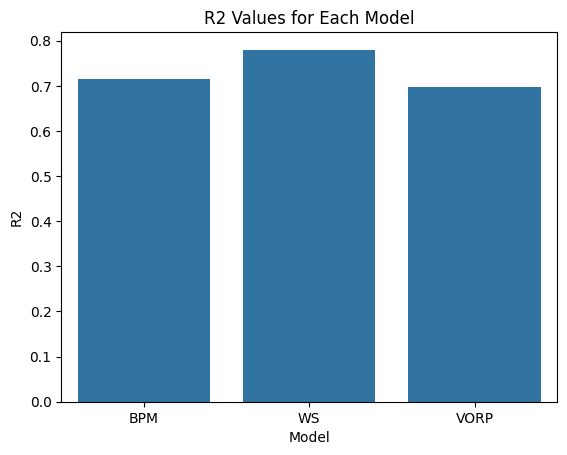

In [380]:
df_r2 = pd.DataFrame({
    'Model': ['BPM', 'WS', 'VORP'],
    'R2': [0.716, 0.78, 0.697]
})

# Create a bar plot
sns.barplot(x='Model', y='R2', data=df_r2)

# Add labels and title
plt.xlabel('Model')
plt.ylabel('R2')
plt.title('R2 Values for Each Model')

# Show the plot
plt.show()

# Overall Summary


- TS% cemented itself as an important efficiency metric as it was selected by all the regression models and had very strong positive coefficients. This indicates that it is a reliable predictor for player value, which was represented by BPM, VORP, and WS.
- USG% on its own is penalized, showing a negative impact on value. That is, unless it is paired with an efficiency or productivity metric (TS%\*USG% or PER*USG%) and those combination metrics positively influence value, indicating that usage is beneficial only when paired with one of those metrics.
- PER showed multicollinearity when put with TS% in certain situations, due to their overall correlation that we say during the correlation heatmap. PER alone was helpful in some models, but it was usually dropped since terms like PER*USG% provided context for the variables.
- In terms of predictability, Win Shares was the most predicatble at $R^2 ≈ 0.78$, BPM was next at $R^2≈ 0.72$, and VORP below that at $R^2 ≈ 0.70$.

Overall, the model that considered usage, efficiency, and productivity with usage as context, performed better. Interpreting this, it indicates that players with high-volume usage should be associated with efficiency and productivity to be valuable.